# Kalori Harcamasını Tahmin Etme

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRyHlp9vr7z25BULvW67XxQkCGlBR27hsX3uw&s">

Bu projede, bireylerin fiziksel özellikleri ve egzersiz verileri kullanılarak harcanan kalori miktarını tahmin etmeye yönelik bir makine öğrenmesi modeli geliştirilmesi amaçlanmaktadır. Yaş, boy, kilo, egzersiz süresi, kalp atış hızı ve vücut sıcaklığı gibi değişkenlerin kalori tüketimi üzerindeki etkisi analiz edilerek problem regresyon çerçevesinde ele alınmıştır. Çalışmanın temel amacı, fiziksel aktivite sırasında harcanan enerji miktarını doğru bir şekilde tahmin edebilen bir model oluşturarak spor, sağlık ve performans takibi alanlarında veri temelli karar süreçlerine katkı sağlamaktır.

### Sütun Açıklamaları

**User_ID**
→ Her kullanıcıya ait benzersiz kimlik numarasını ifade eder.

**Gender**
→ Kullanıcının cinsiyet bilgisini gösterir.

**Age**
→ Kullanıcının yaşını belirtir.

**Height**
→ Kullanıcının boyunu (genellikle cm cinsinden) ifade eder.

**Weight**
→ Kullanıcının kilosunu (genellikle kg cinsinden) gösterir.

**Duration**
→ Egzersizin süresini (genellikle dakika cinsinden) belirtir.

**Heart_Rate**
→ Egzersiz sırasında ölçülen kalp atış hızını gösterir.

**Body_Temp**
→ Egzersiz sırasında ölçülen vücut sıcaklığını ifade eder.

**Calories**
→ Egzersiz sırasında harcanan kalori miktarını gösteren hedef (tahmin edilecek) değişkendir.

### Veri seti kaynağı
https://www.kaggle.com/competitions/playground-series-s5e5/data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/kaloritahmini/calories.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


import warnings
warnings.filterwarnings("ignore")


In [3]:
path = "/kaggle/input/kaloritahmini/calories.csv"

df = pd.read_csv(path)

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
df.shape

(15000, 9)

In [5]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [7]:
df.columns

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories'],
      dtype='object')

In [8]:
df.corr(numeric_only=True)

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
User_ID,1.000000,-0.001827,-0.013520,-0.011603,-0.002751,-0.000457,0.000923,-0.001661
Age,-0.001827,1.000000,0.009554,0.090094,0.013247,0.010482,0.013175,0.154395
Height,-0.013520,0.009554,1.000000,0.958451,-0.004625,0.000528,0.001200,0.017537
Weight,-0.011603,0.090094,0.958451,1.000000,-0.001884,0.004311,0.004095,0.035481
Duration,-0.002751,0.013247,-0.004625,-0.001884,1.000000,0.852869,0.903167,0.955421
Heart_Rate,-0.000457,0.010482,0.000528,0.004311,0.852869,1.000000,0.771529,0.897882
Body_Temp,0.000923,0.013175,0.001200,0.004095,0.903167,0.771529,1.000000,0.824558
Calories,-0.001661,0.154395,0.017537,0.035481,0.955421,0.897882,0.824558,1.000000


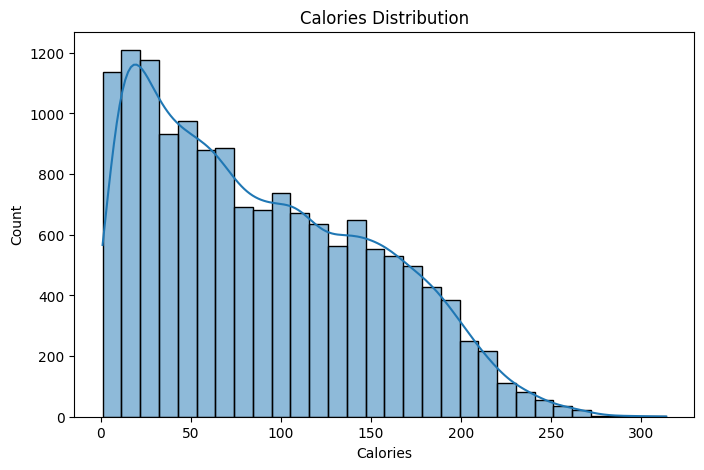

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Calories"], bins=30, kde=True)
plt.title("Calories Distribution")
plt.show()


Kalori değerlerinin sağa çarpık dağıldığı ve çoğu gözlemin düşük-orta aralıkta toplandığı görülmektedir.

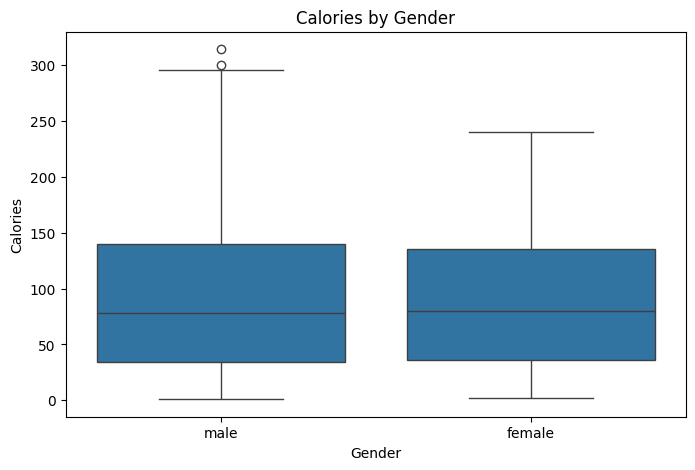

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Gender", y="Calories", data=df)
plt.title("Calories by Gender")
plt.show()


Erkek ve kadınların kalori harcamaları benzer dağılım göstermekte olup medyan değerler birbirine oldukça yakındır.

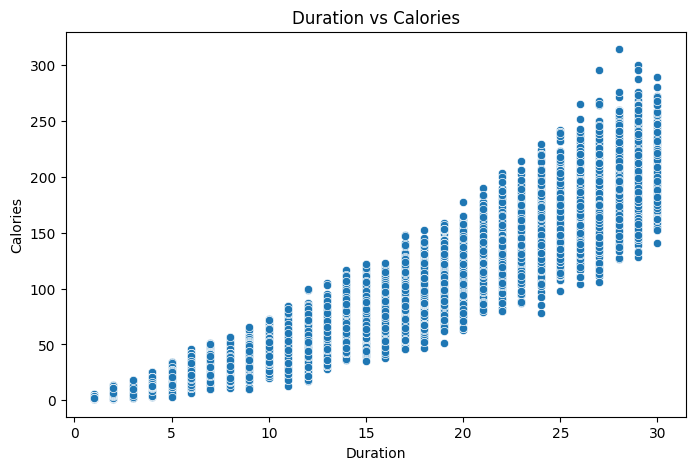

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Duration", y="Calories", data=df)
plt.title("Duration vs Calories")
plt.show()


Egzersiz süresi arttıkça harcanan kalori miktarının güçlü ve doğrusal şekilde arttığı görülmektedir.

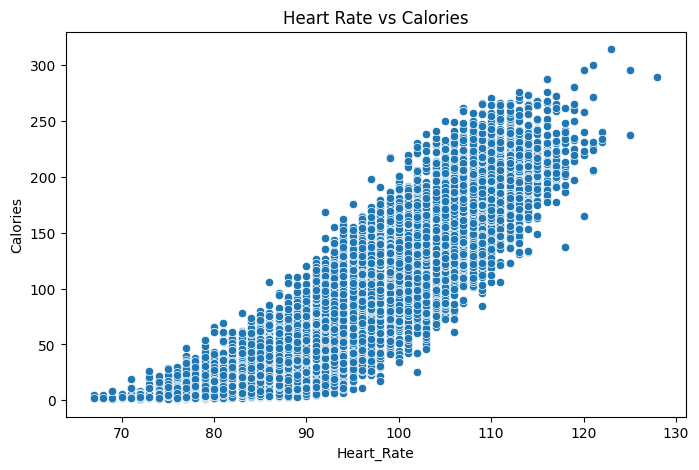

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Heart_Rate", y="Calories", data=df)
plt.title("Heart Rate vs Calories")
plt.show()


Kalp atış hızı yükseldikçe harcanan kalori miktarı da belirgin biçimde artmaktadır.

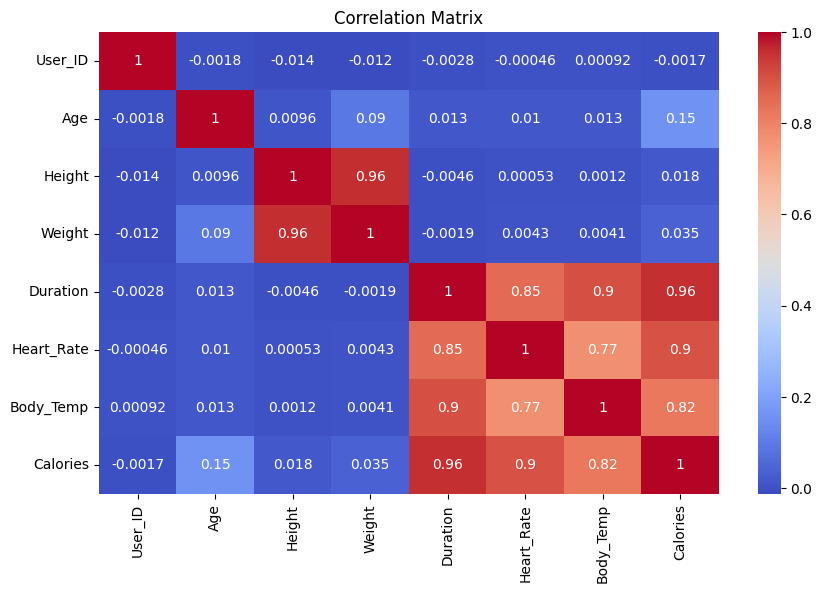

In [13]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Calories değişkeninin en güçlü ilişkiyi Duration (0.96), Heart_Rate (0.90) ve Body_Temp (0.82) ile gösterdiği görülmektedir.

In [14]:
df = df.drop("User_ID", axis=1)


In [15]:
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)
df.head()


,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Gender_male
0,68,190.0,94.0,29.0,105.0,40.8,231.0,True
1,20,166.0,60.0,14.0,94.0,40.3,66.0,False
2,69,179.0,79.0,5.0,88.0,38.7,26.0,True
3,34,179.0,71.0,13.0,100.0,40.5,71.0,False
4,27,154.0,58.0,10.0,81.0,39.8,35.0,False


In [16]:
df.head()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Gender_male
0,68,190.0,94.0,29.0,105.0,40.8,231.0,True
1,20,166.0,60.0,14.0,94.0,40.3,66.0,False
2,69,179.0,79.0,5.0,88.0,38.7,26.0,True
3,34,179.0,71.0,13.0,100.0,40.5,71.0,False
4,27,154.0,58.0,10.0,81.0,39.8,35.0,False


In [17]:
x = df.drop("Calories", axis=1)
y = df["Calories"]


In [18]:
print("X shape:", x.shape)
print("y shape:", y.shape)


X shape: (15000, 7)
y shape: (15000,)


In [19]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


x_train shape: (12000, 7)
x_test shape : (3000, 7)
y_train shape: (12000,)
y_test shape : (3000,)


In [21]:
model1 = RandomForestRegressor(random_state=42)
model1.fit(x_train, y_train)

tahmin1 = model1.predict(x_test)

r2_1 = r2_score(y_test, tahmin1)
r2_1

0.998221953940476

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model2 = LinearRegression()
model2.fit(x_train, y_train)

tahmin2 = model2.predict(x_test)

r2_2 = r2_score(y_test, tahmin2)
print("model1 (Linear Regression) R2:", r2_2)


model1 (Linear Regression) R2: 0.9672937151257295


In [23]:
from sklearn.ensemble import GradientBoostingRegressor

model3 = GradientBoostingRegressor(random_state=42)
model3.fit(x_train, y_train)

tahmin3 = model3.predict(x_test)

r2_3 = r2_score(y_test, tahmin3)
print("model3 (Gradient Boosting) R2:", r2_3)


model3 (Gradient Boosting) R2: 0.9967670534446199


In [24]:
print("\n===== MODEL KARŞILAŞTIRMA (R2) =====")
print("Linear Regression :", r2_1)
print("Random Forest     :", r2_2)
print("Gradient Boosting :", r2_3)



===== MODEL KARŞILAŞTIRMA (R2) =====
Linear Regression : 0.998221953940476
Random Forest     : 0.9672937151257295
Gradient Boosting : 0.9967670534446199


**Ne Anlama Geliyor?**

Linear Regression (0.9982) → Verinin %99.82’sini açıklıyor → Neredeyse mükemmel.

Gradient Boosting (0.9968) → Çok güçlü, ama lineerden biraz daha düşük.

Random Forest (0.9673) → Güçlü ama diğer ikisinin gerisinde.

**Bu kadar yüksek R² genelde iki şey gösterir:**

1-Veri gerçekten çok lineer ilişkili
2-Ya da feature’lar ile hedef arasında çok güçlü doğrudan matematiksel bağ var

Zaten korelasyon matrisinde görmüştük:

Duration → Calories çok yüksek korelasyon

Heart_Rate → Calories çok yüksek

Body_Temp → Calories çok yüksek

Bu yüzden Linear Regression burada en mantıklı model çıkmış.

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np


def algo_test(df, target="Calories", drop_cols=("User_ID",), random_state=42):
    # ==============================
    # 1) Temizleme: drop + encoding
    # ==============================
    df2 = df.copy()

    # User_ID gibi kullanılmayacak sütunları düş
    for c in drop_cols:
        if c in df2.columns:
            df2 = df2.drop(c, axis=1)

    # Gender (ve varsa diğer object sütunları) one-hot
    cat_cols = df2.select_dtypes(include="object").columns
    if len(cat_cols) > 0:
        df2 = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

    # X / y
    x = df2.drop(target, axis=1)
    y = df2[target]

    # ==============================
    # 2) Train-Test Split
    # ==============================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=random_state
    )

    # ==============================
    # 3) Modeller
    # (Scaling gerekenleri Pipeline ile verdim)
    # ==============================
    models = [
        ("Linear Regression", Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])),
        ("Ridge",            Pipeline([("scaler", StandardScaler()), ("model", Ridge())])),
        ("Lasso",            Pipeline([("scaler", StandardScaler()), ("model", Lasso())])),
        ("ElasticNet",       Pipeline([("scaler", StandardScaler()), ("model", ElasticNet())])),
        ("Extra Trees",      ExtraTreesRegressor(random_state=random_state)),
        ("Gradient Boosting",GradientBoostingRegressor(random_state=random_state)),
        ("KNN",              Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())])),
        ("Decision Tree",    DecisionTreeRegressor(random_state=random_state)),
    ]

    # ==============================
    # 4) Sonuç tablosu
    # ==============================
    result = pd.DataFrame(columns=["R_Squared", "RMSE", "MAE"])

    for name, model in models:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        r2   = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)

        result.loc[name] = [r2, rmse, mae]

    # R²'ye göre sırala
    rtable = result.sort_values("R_Squared", ascending=False)

    return rtable


In [26]:
algo_test(df) 

,R_Squared,RMSE,MAE
Extra Trees,0.998764,2.233446,1.452083
Gradient Boosting,0.996767,3.612132,2.605547
KNN,0.993518,5.114799,3.714133
Decision Tree,0.992943,5.336822,3.443000
Linear Regression,0.967294,11.488940,8.441514
Ridge,0.967292,11.489210,8.441186
Lasso,0.960899,12.561926,9.144387
ElasticNet,0.900801,20.008662,15.301911


## Sonuç

Bu veri setinde kalori tahmini için en güçlü model Extra Trees olup R² = 0.9988 ile neredeyse kusursuz bir açıklama gücüne sahiptir; ayrıca çok düşük RMSE (2.23) ve MAE (1.45) değerleri, modelin gerçek kalori değerlerine son derece yakın tahminler ürettiğini göstermektedir. Ensemble tabanlı modellerin (Extra Trees ve Gradient Boosting) açık ara üstün performansı, veride güçlü ve doğrusal olmayan ilişkiler bulunduğunu ortaya koymaktadır.